# Prompt Speed Benchmark and EDA 

## Cell 1 — Imports 

In [12]:
import os
import sys
import time
import json
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from dotenv import load_dotenv
from openai import AzureOpenAI

PROJECT_ROOT = Path("__file__").resolve().parent.parent
sys.path.insert(0, str(PROJECT_ROOT))

load_dotenv(dotenv_path=PROJECT_ROOT / ".env")

client = AzureOpenAI(
    api_key=os.getenv("OPENAI_API_4_KEY"),
    api_version=os.getenv("OPENAI_API_4_VERSION"),
    azure_endpoint=os.getenv("OPENAI_4_BASE_URL"),
)
DEPLOYMENT = os.getenv("OPEN_API_4_ENGINE")

print(f"✅ Using deployment: {DEPLOYMENT}")

✅ Using deployment: gpt-4o


## DOWNLOAD THE MOEDL


In [14]:
import gdown
import os
# === CONFIG ===
file_id = "10BY40d66Es9QEmgoGeWCao3b8bK7-4ay"
output_dir = "model/best"
filename = "model.safetensors"
# =================

# Create folder if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

file_path = os.path.join(output_dir, filename)

# Download only if file does not exist
if not os.path.exists(file_path):
    print("Model not found. Downloading...")
    
    url = f"https://drive.google.com/uc?id={file_id}"
    gdown.download(url, file_path, quiet=False)
    
    print("Download completed.")
else:
    print("Model already exists. Skipping download.")

Model already exists. Skipping download.


## Load Prompts

In [15]:
from app.pormpts import (
    INTENT_CLASSIFICATION_FEATURE_TRIGGER_PROMPT,
    TRIGGER_ONLY_CLASSIFICATION_PROMPT,
    TIEREED_DISCOUNT_TRIGGER_ONLY_CLASSIFICATION_PROMPT,
    INTENT_CLASSIFICATION_PROMPT
    
)

print("Prompts loaded successfully.")
print(f"Combined prompt length : {len(INTENT_CLASSIFICATION_FEATURE_TRIGGER_PROMPT):,} chars")
print(f"Trigger-only prompt length: {len(TRIGGER_ONLY_CLASSIFICATION_PROMPT):,} chars")
print(f"Tiered-Discount:{len(TIEREED_DISCOUNT_TRIGGER_ONLY_CLASSIFICATION_PROMPT):,} chars")
print(f"Intent-Classification:{len(INTENT_CLASSIFICATION_PROMPT):,} chars")


Prompts loaded successfully.
Combined prompt length : 1,651 chars
Trigger-only prompt length: 662 chars
Tiered-Discount:978 chars
Intent-Classification:1,091 chars


## Select Benchmark Examples from `generated_data.py`

In [ ]:
# Only use these benchmark examples
BENCHMARK_EXAMPLES=[
    # Free Gift
    ("Spend $100 and get a free gift", "free_gift"),
    ("Buy 2 from Skincare and get a sample free", "free_gift"),
    ("VIP customers buy 3 products and get a free tote bag", "free_gift"),

    # Buy X Get Y
    ("Buy 2 shirts and get 1 cap free", "buy_x_get_y"),
    ("Buy 2 products from Collection A and get 50% off Collection B", "buy_x_get_y"),
    ("VIP customers buy 3 items and get the cheapest one free", "buy_x_get_y"),
    
    # Tiered Discount
    ("Buy 2 get 10%, buy 4 get 20%", "tiered_discount"),
    ("Spend $100 get 10% off, spend $200 get 20% off", "tiered_discount"),
    ("VIP customers spend $150 get 15%, spend $300 get 25%", "tiered_discount"),
   
    # Unsupported
    ("Spend $0 and unlock surprises.", "unsupported"),
    ("Hi, can we motivate buyers with perks?", "unsupported"),
    ("Buy things and gain undefined rewards.", "unsupported"),
    
]

SAMPLES_PER_INTENT = {
    "free_gift": 3,
    "buy_x_get_y": 3,
    "tiered_discount":3,
    "unsupported": 3,
}

# ── Deterministic selection ────────────────────────────────────────────────────
selected: list[dict] = []
seen: dict[str, int] = {k: 0 for k in SAMPLES_PER_INTENT}

for text, intent in BENCHMARK_EXAMPLES:
    if intent in seen and seen[intent] < SAMPLES_PER_INTENT[intent]:
        selected.append({"text": text, "intent": intent})
        seen[intent] += 1

print(f"\n📋 Benchmark dataset — {len(selected)} examples selected:")
for intent, count in SAMPLES_PER_INTENT.items():
    subset = [s for s in selected if s["intent"] == intent]
    print(f"  {intent:<20} → {len(subset)} examples")
    for s in subset:
        print(
            f"      • {s['text'][:80]}..."
            if len(s["text"]) > 80
            else f"      • {s['text']}"
        )


📋 Benchmark dataset — 12 examples selected:
  free_gift            → 3 examples
      • Spend $100 and get a free gift
      • Buy 2 from Skincare and get a sample free
      • VIP customers buy 3 products and get a free tote bag
  buy_x_get_y          → 3 examples
      • Buy 2 shirts and get 1 cap free
      • Buy 2 products from Collection A and get 50% off Collection B
      • VIP customers buy 3 items and get the cheapest one free
  tiered_discount      → 3 examples
      • Buy 2 get 10%, buy 4 get 20%
      • Spend $100 get 10% off, spend $200 get 20% off
      • VIP customers spend $150 get 15%, spend $300 get 25%
  unsupported          → 3 examples
      • Spend $0 and unlock surprises.
      • Hi, can we motivate buyers with perks?
      • Buy things and gain undefined rewards.


## Benchmark Runner

Defines four helper functions:
1. **`call_combined`** — single LLM call for intent + trigger.
2. **`call_trigger_only`** — trigger detection with pre-known intent.
3. **`call_intent_then_trigger`** — LLM intent → LLM trigger (2-step).
4. **`call_model_then_trigger`** — **local trained model** intent → LLM trigger (2-step).
   - `free_gift` / `buy_x_get_y` → `TRIGGER_ONLY_CLASSIFICATION_PROMPT`
   - `tiered_discount` → `TIEREED_DISCOUNT_TRIGGER_ONLY_CLASSIFICATION_PROMPT`
   - `unsupported` → returns `{}` immediately (no API call).

In [4]:
from app.pormpts import (
    INTENT_CLASSIFICATION_FEATURE_TRIGGER_PROMPT,
    TRIGGER_ONLY_CLASSIFICATION_PROMPT,
    TIEREED_DISCOUNT_TRIGGER_ONLY_CLASSIFICATION_PROMPT,
    INTENT_CLASSIFICATION_PROMPT,
)

# ── import the local trained model classifier ─────────────────────────────
from intentClassifier.classify import classify as model_classify


def call_combined(query: str) -> tuple[dict, float, dict]:
    """Combined intent + trigger via INTENT_CLASSIFICATION_FEATURE_TRIGGER_PROMPT."""
    t0 = time.perf_counter()
    response = client.chat.completions.create(
        model=DEPLOYMENT,
        messages=[
            {"role": "system", "content": INTENT_CLASSIFICATION_FEATURE_TRIGGER_PROMPT},
            {"role": "user",   "content": query},
        ],
        response_format={"type": "json_object"},
        top_p=0.0,
        temperature=1,
    )
    elapsed = time.perf_counter() - t0
    reply = json.loads(response.choices[0].message.content)
    usage = {
        "prompt_tokens":     response.usage.prompt_tokens,
        "completion_tokens": response.usage.completion_tokens,
        "total_tokens":      response.usage.total_tokens,
    }
    return reply, elapsed, usage


def call_trigger_only(query: str, intent: str) -> tuple[dict, float, dict | None]:
    """Trigger-only prompt with pre-known intent.

    - 'unsupported' → skip API, return ({}, 0.0, None).
    - 'tiered_discount' → TIEREED_DISCOUNT_TRIGGER_ONLY_CLASSIFICATION_PROMPT.
    - otherwise      → TRIGGER_ONLY_CLASSIFICATION_PROMPT.
    """
    if intent == "unsupported":
        return {}, 0.0, None

    system_prompt = (
        TIEREED_DISCOUNT_TRIGGER_ONLY_CLASSIFICATION_PROMPT
        if intent == "tiered_discount"
        else TRIGGER_ONLY_CLASSIFICATION_PROMPT
    )

    user_msg = f"intent: {intent}\nuser_query: {query}"
    t0 = time.perf_counter()
    response = client.chat.completions.create(
        model=DEPLOYMENT,
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user",   "content": user_msg},
        ],
        response_format={"type": "json_object"},
        top_p=0.0,
        temperature=1,
    )
    elapsed = time.perf_counter() - t0
    reply = json.loads(response.choices[0].message.content)
    usage = {
        "prompt_tokens":     response.usage.prompt_tokens,
        "completion_tokens": response.usage.completion_tokens,
        "total_tokens":      response.usage.total_tokens,
    }
    return reply, elapsed, usage


def call_intent_then_trigger(query: str) -> tuple[dict, float, dict, float, str]:
    """Two-step pipeline: INTENT_CLASSIFICATION_PROMPT → trigger prompt.

    Returns (trigger_reply, total_latency, total_usage, intent_latency, classified_intent).
    - 'unsupported' → only intent call, trigger step skipped.
    - 'tiered_discount' → TIEREED_DISCOUNT_TRIGGER_ONLY_CLASSIFICATION_PROMPT.
    - otherwise → TRIGGER_ONLY_CLASSIFICATION_PROMPT.
    """
    # Step 1: intent classification
    t0 = time.perf_counter()
    resp_intent = client.chat.completions.create(
        model=DEPLOYMENT,
        messages=[
            {"role": "system", "content": INTENT_CLASSIFICATION_PROMPT},
            {"role": "user",   "content": query},
        ],
        response_format={"type": "json_object"},
        top_p=0.0,
        temperature=1,
    )
    intent_latency = time.perf_counter() - t0
    classified_intent = json.loads(resp_intent.choices[0].message.content).get("intent", "unsupported")
    intent_usage = {
        "prompt_tokens":     resp_intent.usage.prompt_tokens,
        "completion_tokens": resp_intent.usage.completion_tokens,
        "total_tokens":      resp_intent.usage.total_tokens,
    }

    # Step 2: trigger detection (skip for unsupported)
    if classified_intent == "unsupported":
        return {}, intent_latency, intent_usage, intent_latency, classified_intent

    system_prompt = (
        TIEREED_DISCOUNT_TRIGGER_ONLY_CLASSIFICATION_PROMPT
        if classified_intent == "tiered_discount"
        else TRIGGER_ONLY_CLASSIFICATION_PROMPT
    )
    user_msg = f"intent: {classified_intent}\nuser_query: {query}"
    t1 = time.perf_counter()
    resp_trigger = client.chat.completions.create(
        model=DEPLOYMENT,
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user",   "content": user_msg},
        ],
        response_format={"type": "json_object"},
        top_p=0.0,
        temperature=1,
    )
    trigger_latency = time.perf_counter() - t1
    trigger_reply = json.loads(resp_trigger.choices[0].message.content)
    trigger_usage = {
        "prompt_tokens":     resp_trigger.usage.prompt_tokens,
        "completion_tokens": resp_trigger.usage.completion_tokens,
        "total_tokens":      resp_trigger.usage.total_tokens,
    }
    total_latency = intent_latency + trigger_latency
    total_usage = {
        "prompt_tokens":     intent_usage["prompt_tokens"]     + trigger_usage["prompt_tokens"],
        "completion_tokens": intent_usage["completion_tokens"] + trigger_usage["completion_tokens"],
        "total_tokens":      intent_usage["total_tokens"]      + trigger_usage["total_tokens"],
    }
    return trigger_reply, total_latency, total_usage, intent_latency, classified_intent


def call_model_then_trigger(query: str) -> tuple[dict, float, dict | None, float, str]:
    """Two-step pipeline: Local trained model → trigger prompt (AzureOpenAI).

    Step 1: Use the fine-tuned local DistilBERT model (classify.py) to predict intent.
    Step 2: Call AzureOpenAI with the appropriate trigger-extraction prompt:
        - 'free_gift' or 'buy_x_get_y' → TRIGGER_ONLY_CLASSIFICATION_PROMPT
        - 'tiered_discount'             → TIEREED_DISCOUNT_TRIGGER_ONLY_CLASSIFICATION_PROMPT
        - 'unsupported'                 → skip API, return ({}, total_latency, None, model_latency, 'unsupported')

    Returns (trigger_reply, total_latency, trigger_usage, model_latency, classified_intent).
    trigger_usage is None for 'unsupported'.
    """
    # Step 1: local model intent classification
    t0 = time.perf_counter()
    model_result = model_classify(query)   # returns {label, confidence, scores, latency_ms, text}
    model_latency = time.perf_counter() - t0
    classified_intent = model_result["label"]

    # Step 2: trigger detection (skip for unsupported)
    if classified_intent == "unsupported":
        return {}, model_latency, None, model_latency, classified_intent

    system_prompt = (
        TIEREED_DISCOUNT_TRIGGER_ONLY_CLASSIFICATION_PROMPT
        if classified_intent == "tiered_discount"
        else TRIGGER_ONLY_CLASSIFICATION_PROMPT
    )
    user_msg = f"intent: {classified_intent}\nuser_query: {query}"
    t1 = time.perf_counter()
    resp_trigger = client.chat.completions.create(
        model=DEPLOYMENT,
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user",   "content": user_msg},
        ],
        response_format={"type": "json_object"},
        top_p=0.0,
        temperature=1,
    )
    trigger_latency = time.perf_counter() - t1
    trigger_reply = json.loads(resp_trigger.choices[0].message.content)
    trigger_usage = {
        "prompt_tokens":     resp_trigger.usage.prompt_tokens,
        "completion_tokens": resp_trigger.usage.completion_tokens,
        "total_tokens":      resp_trigger.usage.total_tokens,
    }
    total_latency = model_latency + trigger_latency
    return trigger_reply, total_latency, trigger_usage, model_latency, classified_intent


print("✅ Helper functions defined: call_combined, call_trigger_only, call_intent_then_trigger, call_model_then_trigger.")


✅ Helper functions defined: call_combined, call_trigger_only, call_intent_then_trigger, call_model_then_trigger.


/Users/yogarajkomati/miniconda3/envs/Skailama/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Run the Benchmark

In [5]:
results: list[dict] = []

total = len(selected)
for i, example in enumerate(selected, 1):
    text   = example["text"]
    intent = example["intent"]

    label = (f"[{i:02d}/{total}] intent={intent:<20} | query={text[:55]}..."
             if len(text) > 55
             else f"[{i:02d}/{total}] intent={intent:<20} | query={text}")
    print(label)

    # ── 1. Combined prompt ──────────────────────────────────────────
    try:
        combined_reply, combined_latency, combined_usage = call_combined(text)
        print(f"  combined            → {combined_latency:.3f}s | {combined_reply}")
    except Exception as e:
        combined_reply, combined_latency, combined_usage = {}, None, None
        print(f"  combined            → ERROR: {e}")

    # ── 2. Trigger-only (pre-known intent) ─────────────────────────
    try:
        trigger_reply, trigger_latency, trigger_usage = call_trigger_only(text, intent)
        print(f"  trigger-only        → {trigger_latency:.3f}s | {trigger_reply}")
    except Exception as e:
        trigger_reply, trigger_latency, trigger_usage = {}, None, None
        print(f"  trigger-only        → ERROR: {e}")

    # ── 3. Intent-then-trigger (two-step pipeline, LLM intent) ──────
    try:
        itt_reply, itt_latency, itt_usage, itt_intent_lat, itt_intent = call_intent_then_trigger(text)
        print(f"  intent+trigger (2step) → {itt_latency:.3f}s (intent={itt_intent_lat:.3f}s, intent='{itt_intent}') | {itt_reply}")
    except Exception as e:
        itt_reply, itt_latency, itt_usage, itt_intent_lat, itt_intent = {}, None, None, None, None
        print(f"  intent+trigger (2step) → ERROR: {e}")

    # ── 4. Model-then-trigger (local model intent + LLM trigger) ────
    try:
        mtt_reply, mtt_latency, mtt_usage, mtt_model_lat, mtt_intent = call_model_then_trigger(text)
        print(f"  model+trigger  (2step) → {mtt_latency:.3f}s (model={mtt_model_lat:.3f}s, intent='{mtt_intent}') | {mtt_reply}")
    except Exception as e:
        mtt_reply, mtt_latency, mtt_usage, mtt_model_lat, mtt_intent = {}, None, None, None, None
        print(f"  model+trigger  (2step) → ERROR: {e}")

    results.append({
        "intent":          intent,
        "text":            text,
        # function 1 – combined
        "combined_latency": combined_latency,
        "combined_reply":   combined_reply,
        "combined_usage":   combined_usage,
        # function 2 – trigger-only
        "trigger_latency":  trigger_latency,
        "trigger_reply":    trigger_reply,
        "trigger_usage":    trigger_usage,
        # function 3 – intent-then-trigger (LLM intent)
        "itt_latency":      itt_latency,
        "itt_reply":        itt_reply,
        "itt_usage":        itt_usage,
        "itt_intent_lat":   itt_intent_lat,
        "itt_intent":       itt_intent,
        # function 4 – model-then-trigger (local model intent)
        "mtt_latency":      mtt_latency,
        "mtt_reply":        mtt_reply,
        "mtt_usage":        mtt_usage,
        "mtt_model_lat":    mtt_model_lat,
        "mtt_intent":       mtt_intent,
    })

print(f"\n✅ Benchmark complete — {len(results)} examples processed.")


[01/12] intent=free_gift            | query=Spend $100 and get a free gift
  combined            → 2.069s | {'feature': 'free_gift', 'trigger': {'type': 'cart_subtotal', 'operator': '>=', 'value': 100}}
  trigger-only        → 0.867s | {'feature': 'free_gift', 'trigger': {'type': 'cart_subtotal', 'operator': '>=', 'value': 100}}
  intent+trigger (2step) → 1.852s (intent=0.988s, intent='free_gift') | {'feature': 'free_gift', 'trigger': {'type': 'cart_subtotal', 'operator': '>=', 'value': 100}}
  model+trigger  (2step) → 2.218s (model=1.389s, intent='free_gift') | {'feature': 'free_gift', 'trigger': {'type': 'cart_subtotal', 'operator': '>=', 'value': 100}}
[02/12] intent=free_gift            | query=Buy 2 from Skincare and get a sample free
  combined            → 1.116s | {'feature': 'free_gift', 'trigger': {'type': 'collection_quantity', 'operator': '>=', 'value': 2}}
  trigger-only        → 0.958s | {'feature': 'free_gift', 'trigger': {'type': 'collection_quantity', 'operator': '>=',

## Cell 6 — Summary Table

In [6]:
from collections import defaultdict

INTENTS = ["free_gift", "buy_x_get_y", "tiered_discount", "unsupported"]

combined_by_intent = defaultdict(list)
trigger_by_intent  = defaultdict(list)
itt_by_intent      = defaultdict(list)
mtt_by_intent      = defaultdict(list)

for r in results:
    if r["combined_latency"] is not None:
        combined_by_intent[r["intent"]].append(r["combined_latency"])
    if r["trigger_latency"] is not None:
        trigger_by_intent[r["intent"]].append(r["trigger_latency"])
    if r["itt_latency"] is not None:
        itt_by_intent[r["intent"]].append(r["itt_latency"])
    if r["mtt_latency"] is not None:
        mtt_by_intent[r["intent"]].append(r["mtt_latency"])

# ── Accuracy: how often does each function's classified intent match ground truth? ──
def intent_from_reply(reply, key="feature"):
    """Extract the intent label from a reply dict."""
    return reply.get(key) if isinstance(reply, dict) else None

combined_correct = sum(
    1 for r in results
    if intent_from_reply(r["combined_reply"]) == r["intent"]
)
trigger_correct = sum(
    1 for r in results
    if r["intent"] == "unsupported"   # trigger-only skips unsupported → counts as correct
    or intent_from_reply(r["trigger_reply"]) is not None
)
itt_correct = sum(
    1 for r in results
    if r.get("itt_intent") == r["intent"]
)
mtt_correct = sum(
    1 for r in results
    if r.get("mtt_intent") == r["intent"]
)

n = len(results)
print(f"\n{'='*76}")
print("  ACCURACY SUMMARY")
print(f"{'='*76}")
print(f"  combined              : {combined_correct}/{n} = {combined_correct/n*100:.1f}%")
print(f"  trigger-only          : {trigger_correct}/{n} = {trigger_correct/n*100:.1f}%  (intent pre-known)")
print(f"  intent-then-trigger   : {itt_correct}/{n} = {itt_correct/n*100:.1f}%")
print(f"  model-then-trigger    : {mtt_correct}/{n} = {mtt_correct/n*100:.1f}%  (local model intent)")
print(f"{'='*76}")

# ── Latency table ──────────────────────────────────────────────────────────────
hdr = (f"{'Intent':<22} {'Combined(s)':>12} {'TrigOnly(s)':>12} {'IttTotal(s)':>12} {'MttTotal(s)':>12}")
print("\n" + hdr)
print("-" * len(hdr))
for intent in INTENTS:
    c = np.mean(combined_by_intent.get(intent, [0]))
    t = np.mean(trigger_by_intent.get(intent,  [0]))
    i = np.mean(itt_by_intent.get(intent,      [0]))
    m = np.mean(mtt_by_intent.get(intent,      [0]))
    print(f"{intent:<22} {c:>12.3f} {t:>12.3f} {i:>12.3f} {m:>12.3f}")
print("-" * len(hdr))
all_c = [r["combined_latency"] for r in results if r["combined_latency"] is not None]
all_t = [r["trigger_latency"]  for r in results if r["trigger_latency"]  is not None]
all_i = [r["itt_latency"]      for r in results if r["itt_latency"]      is not None]
all_m = [r["mtt_latency"]      for r in results if r["mtt_latency"]      is not None]
print(f"{'OVERALL MEAN':<22} {np.mean(all_c):>12.3f} {np.mean(all_t):>12.3f} {np.mean(all_i):>12.3f} {np.mean(all_m):>12.3f}")



  ACCURACY SUMMARY
  combined              : 12/12 = 100.0%
  trigger-only          : 9/12 = 75.0%  (intent pre-known)
  intent-then-trigger   : 12/12 = 100.0%
  model-then-trigger    : 10/12 = 83.3%  (local model intent)

Intent                  Combined(s)  TrigOnly(s)  IttTotal(s)  MttTotal(s)
--------------------------------------------------------------------------
free_gift                     1.503        0.881        1.838        1.386
buy_x_get_y                   1.145        0.908        1.822        0.903
tiered_discount               1.289        1.858        3.247        2.601
unsupported                   1.084        0.000        1.012        0.055
--------------------------------------------------------------------------
OVERALL MEAN                  1.255        0.912        1.980        1.236


## Cell 9 — Cost Analysis: Token Usage & Estimated Cost

Computes the **token usage** (prompt + completion) for every API call and estimates the **USD cost** using GPT-4o pricing.

> **Pricing reference** (GPT-4o, mid-2024)  
> | Token type | Price |  
> |---|---|  
> | Prompt (input) | $5.00 / 1 M tokens |  
> | Completion (output) | $15.00 / 1 M tokens |  

Adjust `PRICE_PER_1M_INPUT` / `PRICE_PER_1M_OUTPUT` to match your deployment.

In [7]:
PRICE_PER_1M_INPUT  = 5.00
PRICE_PER_1M_OUTPUT = 15.00

def compute_cost(usage: dict | None) -> float:
    if not usage:
        return 0.0
    return (
        (usage["prompt_tokens"]     / 1_000_000) * PRICE_PER_1M_INPUT
        + (usage["completion_tokens"] / 1_000_000) * PRICE_PER_1M_OUTPUT
    )

tot_c   = {"p": 0, "c": 0, "t": 0, "cost": 0.0}
tot_tr  = {"p": 0, "c": 0, "t": 0, "cost": 0.0}
tot_itt = {"p": 0, "c": 0, "t": 0, "cost": 0.0}
tot_mtt = {"p": 0, "c": 0, "t": 0, "cost": 0.0}
rows = []

for r in results:
    cu  = r.get("combined_usage") or {}
    tu  = r.get("trigger_usage")  or {}
    iu  = r.get("itt_usage")      or {}
    mu  = r.get("mtt_usage")      or {}   # only the trigger API call; model is free
    c_cost   = compute_cost(r.get("combined_usage"))
    t_cost   = compute_cost(r.get("trigger_usage"))
    itt_cost = compute_cost(r.get("itt_usage"))
    mtt_cost = compute_cost(r.get("mtt_usage"))  # local model has no token cost

    for tot, u, cost in [(tot_c, cu, c_cost), (tot_tr, tu, t_cost), (tot_itt, iu, itt_cost), (tot_mtt, mu, mtt_cost)]:
        tot["p"]    += u.get("prompt_tokens", 0)
        tot["c"]    += u.get("completion_tokens", 0)
        tot["t"]    += u.get("total_tokens", 0)
        tot["cost"] += cost

    rows.append({
        "intent": r["intent"],
        "query":  (r["text"][:38] + "…") if len(r["text"]) > 39 else r["text"],
        "cp": cu.get("prompt_tokens",0),  "cc": cu.get("completion_tokens",0),
        "ct": cu.get("total_tokens",0),   "c$": c_cost,
        "tp": tu.get("prompt_tokens",0),  "tc": tu.get("completion_tokens",0),
        "tt": tu.get("total_tokens",0),   "t$": t_cost,
        "ip": iu.get("prompt_tokens",0),  "ic": iu.get("completion_tokens",0),
        "it": iu.get("total_tokens",0),   "i$": itt_cost,
        "mp": mu.get("prompt_tokens",0),  "mc": mu.get("completion_tokens",0),
        "mt": mu.get("total_tokens",0),   "m$": mtt_cost,
    })

HDR = (f"{'#':<3} {'Intent':<18} {'Query':<40} "
       f"{'C-In':>6}{'C-Out':>6}{'C-$':>9} "
       f"{'T-In':>6}{'T-Out':>6}{'T-$':>9} "
       f"{'I-In':>6}{'I-Out':>6}{'I-$':>9} "
       f"{'M-In':>6}{'M-Out':>6}{'M-$':>9}")
print(HDR)
print("-" * len(HDR))
for i, row in enumerate(rows, 1):
    print(f"{i:<3} {row['intent']:<18} {row['query']:<40} "
          f"{row['cp']:>6}{row['cc']:>6}{row['c$']:>9.6f} "
          f"{row['tp']:>6}{row['tc']:>6}{row['t$']:>9.6f} "
          f"{row['ip']:>6}{row['ic']:>6}{row['i$']:>9.6f} "
          f"{row['mp']:>6}{row['mc']:>6}{row['m$']:>9.6f}")
print("-" * len(HDR))
print(f"{'TOT':<3} {'':<18} {'':<40} "
      f"{tot_c['p']:>6}{tot_c['c']:>6}{tot_c['cost']:>9.6f} "
      f"{tot_tr['p']:>6}{tot_tr['c']:>6}{tot_tr['cost']:>9.6f} "
      f"{tot_itt['p']:>6}{tot_itt['c']:>6}{tot_itt['cost']:>9.6f} "
      f"{tot_mtt['p']:>6}{tot_mtt['c']:>6}{tot_mtt['cost']:>9.6f}")

print(f"\n{'='*66}")
print("  COST SUMMARY")
print(f"{'='*66}")
print(f"  combined              — tokens: {tot_c['t']:>7} | cost: ${tot_c['cost']:.6f}")
print(f"  trigger-only          — tokens: {tot_tr['t']:>7} | cost: ${tot_tr['cost']:.6f}")
print(f"  intent-then-trigger   — tokens: {tot_itt['t']:>7} | cost: ${tot_itt['cost']:.6f}")
print(f"  model-then-trigger    — tokens: {tot_mtt['t']:>7} | cost: ${tot_mtt['cost']:.6f}  (model inference is free)")
print(f"{'='*66}")


#   Intent             Query                                      C-In C-Out      C-$   T-In T-Out      T-$   I-In I-Out      I-$   M-In M-Out      M-$
-------------------------------------------------------------------------------------------------------------------------------------------------------
1   free_gift          Spend $100 and get a free gift              483    42 0.003045    207    42 0.001665    548    54 0.003550    207    42 0.001665
2   free_gift          Buy 2 from Skincare and get a sample f…     486    41 0.003045    210    49 0.001785    554    61 0.003685    211    50 0.001805
3   free_gift          VIP customers buy 3 products and get a…     487    41 0.003050    211    41 0.001670    556    53 0.003575    212    42 0.001690
4   buy_x_get_y        Buy 2 shirts and get 1 cap free             485    42 0.003055    210    42 0.001680    553    55 0.003590    210    42 0.001680
5   buy_x_get_y        Buy 2 products from Collection A and g…     490    42 0.003080   

## Cell 7 — Visualisation: Grouped Bar Chart (Mean Latency per Intent, 4 Approaches)

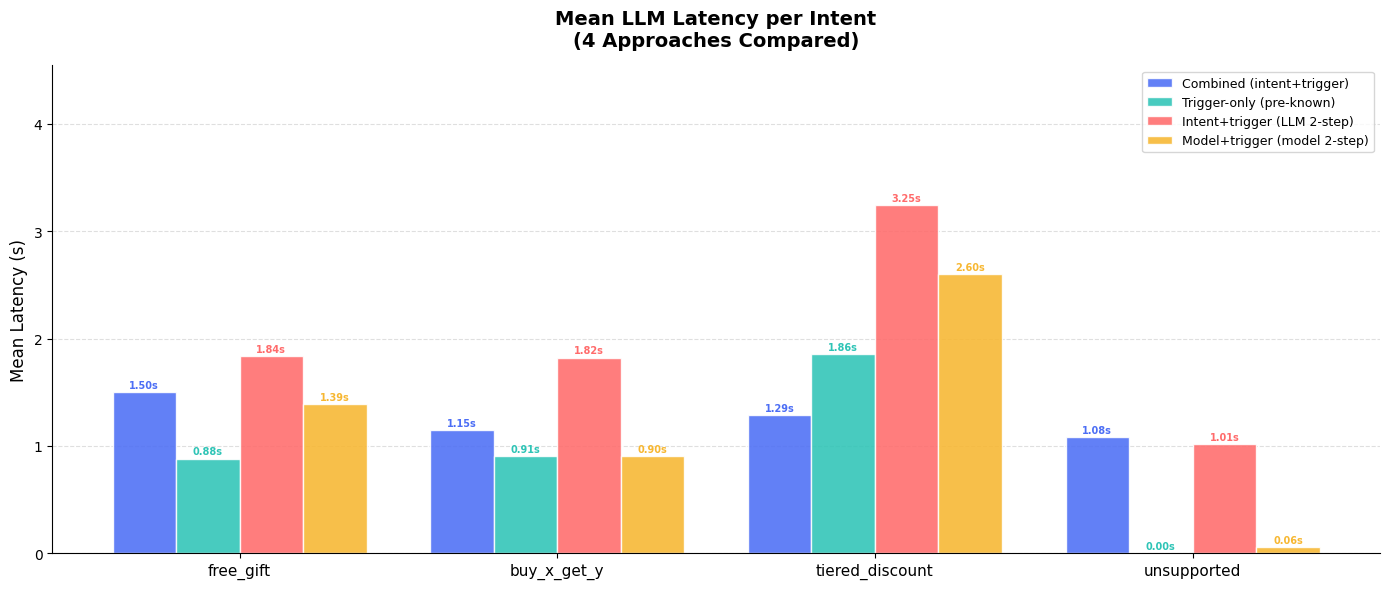

📊 4-way bar chart saved.


In [8]:
fig, ax = plt.subplots(figsize=(14, 6))

x         = np.arange(len(INTENTS))
bw        = 0.20
COLOR_C   = "#4C6EF5"   # indigo  – combined
COLOR_T   = "#2EC4B6"   # teal    – trigger-only
COLOR_I   = "#FF6B6B"   # coral   – intent-then-trigger
COLOR_M   = "#F7B731"   # amber   – model-then-trigger

mc = [np.mean(combined_by_intent.get(i, [0])) for i in INTENTS]
mt = [np.mean(trigger_by_intent.get(i,  [0])) for i in INTENTS]
mi = [np.mean(itt_by_intent.get(i,      [0])) for i in INTENTS]
mm = [np.mean(mtt_by_intent.get(i,      [0])) for i in INTENTS]

offset = 1.5 * bw
b1 = ax.bar(x - offset,        mc, bw, label="Combined (intent+trigger)",    color=COLOR_C, alpha=0.88, edgecolor="white")
b2 = ax.bar(x - offset + bw,   mt, bw, label="Trigger-only (pre-known)",     color=COLOR_T, alpha=0.88, edgecolor="white")
b3 = ax.bar(x - offset + 2*bw, mi, bw, label="Intent+trigger (LLM 2-step)",  color=COLOR_I, alpha=0.88, edgecolor="white")
b4 = ax.bar(x - offset + 3*bw, mm, bw, label="Model+trigger (model 2-step)", color=COLOR_M, alpha=0.88, edgecolor="white")

for bars, color in [(b1, COLOR_C), (b2, COLOR_T), (b3, COLOR_I), (b4, COLOR_M)]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f"{bar.get_height():.2f}s", ha="center", va="bottom",
                fontsize=7, color=color, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(INTENTS, fontsize=11)
ax.set_ylabel("Mean Latency (s)", fontsize=12)
ax.set_title("Mean LLM Latency per Intent\n(4 Approaches Compared)", fontsize=14, fontweight="bold", pad=14)
ax.legend(fontsize=9, framealpha=0.8)
ax.set_ylim(0, max(max(mc), max(mt), max(mi), max(mm)) * 1.4)
ax.spines[["top","right"]].set_visible(False)
ax.yaxis.grid(True, linestyle="--", alpha=0.4)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig("latency_bar_chart_4way.png", dpi=150, bbox_inches="tight")
plt.show()
print("📊 4-way bar chart saved.")


## Cell 8 — Visualisation: Box Plot (Latency Distribution per Intent, 4 Approaches)

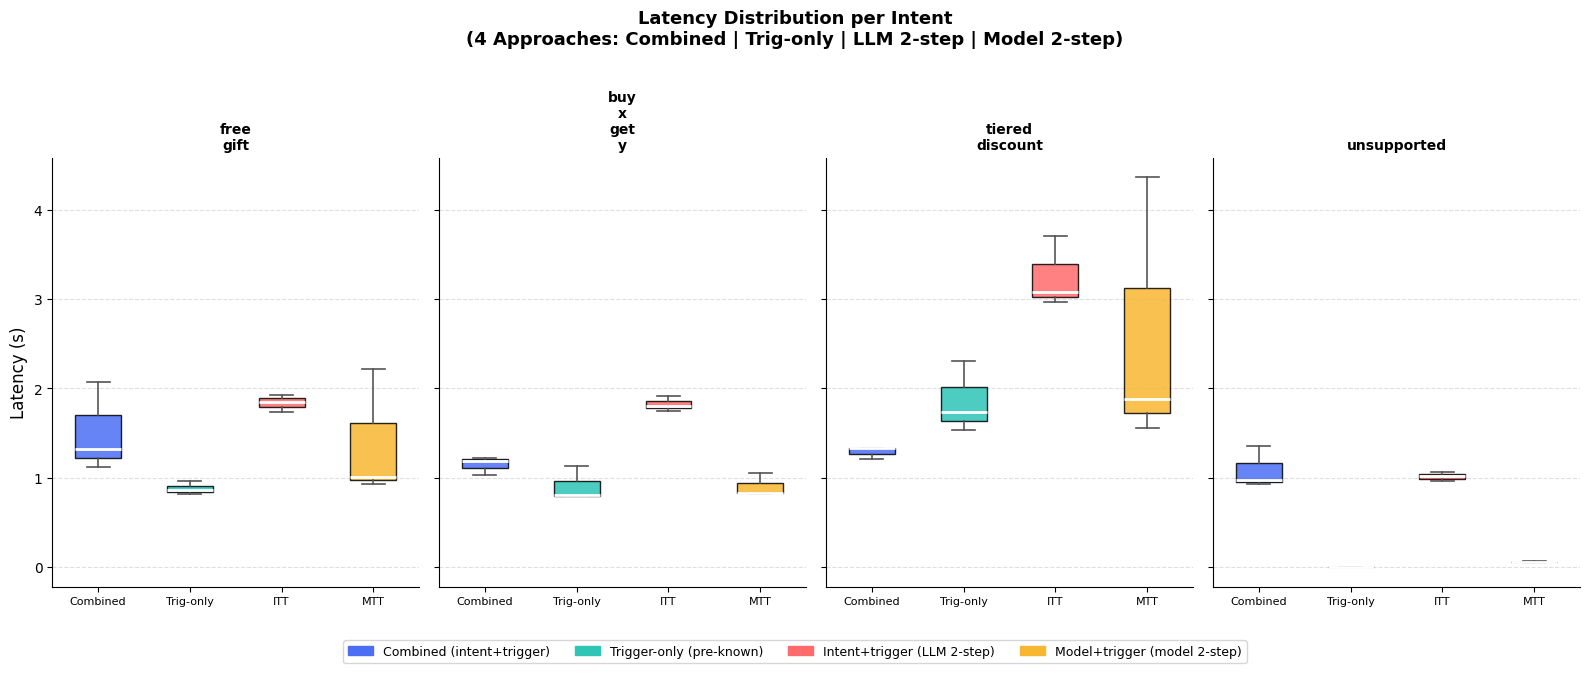

📊 4-way box plot saved.


In [9]:
fig, axes = plt.subplots(1, len(INTENTS), figsize=(16, 6), sharey=True)

COLOR_C = "#4C6EF5"
COLOR_T = "#2EC4B6"
COLOR_I = "#FF6B6B"
COLOR_M = "#F7B731"

LABELS = ["Combined", "Trig-only", "ITT", "MTT"]
COLORS = [COLOR_C, COLOR_T, COLOR_I, COLOR_M]

for ax, intent in zip(axes, INTENTS):
    data = [
        combined_by_intent.get(intent, []),
        trigger_by_intent.get(intent,  []),
        itt_by_intent.get(intent,      []),
        mtt_by_intent.get(intent,      []),
    ]
    bp = ax.boxplot(
        [d if d else [0] for d in data],
        patch_artist=True,
        widths=0.5,
        medianprops={"color": "white", "linewidth": 2},
    )
    for patch, color in zip(bp["boxes"], COLORS):
        patch.set_facecolor(color)
        patch.set_alpha(0.85)
    for whisker in bp["whiskers"]:
        whisker.set(color="#555", linewidth=1.2)
    for cap in bp["caps"]:
        cap.set(color="#555", linewidth=1.2)
    for flier in bp["fliers"]:
        flier.set(marker="o", color="#555", alpha=0.5)

    ax.set_title(intent.replace("_", "\n"), fontsize=10, fontweight="bold")
    ax.set_xticks([1, 2, 3, 4])
    ax.set_xticklabels(LABELS, fontsize=8)
    ax.yaxis.grid(True, linestyle="--", alpha=0.4)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)

axes[0].set_ylabel("Latency (s)", fontsize=12)
fig.suptitle("Latency Distribution per Intent\n(4 Approaches: Combined | Trig-only | LLM 2-step | Model 2-step)",
             fontsize=13, fontweight="bold", y=1.02)

legend_patches = [
    plt.matplotlib.patches.Patch(color=COLOR_C, label="Combined (intent+trigger)"),
    plt.matplotlib.patches.Patch(color=COLOR_T, label="Trigger-only (pre-known)"),
    plt.matplotlib.patches.Patch(color=COLOR_I, label="Intent+trigger (LLM 2-step)"),
    plt.matplotlib.patches.Patch(color=COLOR_M, label="Model+trigger (model 2-step)"),
]
fig.legend(handles=legend_patches, loc="lower center", ncol=4, fontsize=9,
           framealpha=0.8, bbox_to_anchor=(0.5, -0.08))

plt.tight_layout()
plt.savefig("latency_box_plot_4way.png", dpi=150, bbox_inches="tight")
plt.show()
print("📊 4-way box plot saved.")


## Accuracy Comparison — 4 Approaches

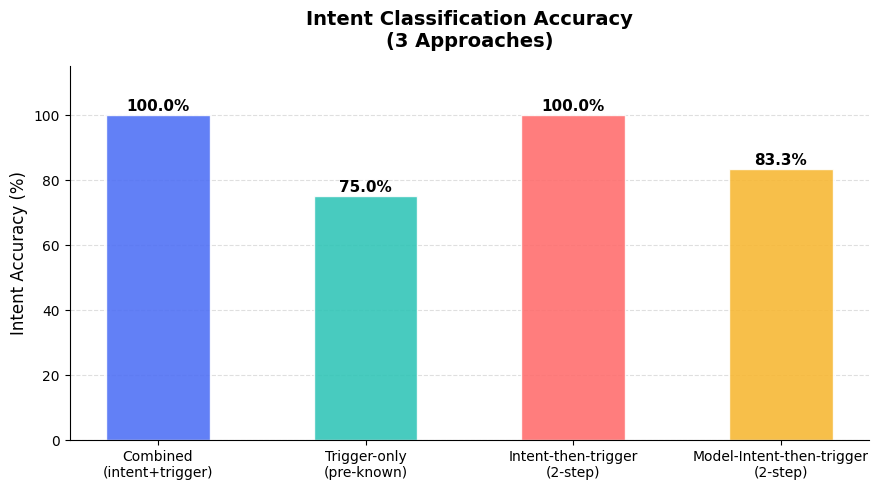

📊 Accuracy chart saved.


In [10]:
# ── Accuracy bar chart (intent classification) ────────────────────────────────
labels_acc = ["Combined\n(intent+trigger)", "Trigger-only\n(pre-known)", "Intent-then-trigger\n(2-step)","Model-Intent-then-trigger\n(2-step)"]
acc_vals   = [combined_correct/n*100, trigger_correct/n*100, itt_correct/n*100,mtt_correct/n*100]
colors_acc = ["#4C6EF5", "#2EC4B6", "#FF6B6B","#F7B731"]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(labels_acc, acc_vals, color=colors_acc, alpha=0.88, edgecolor="white", width=0.5)
for bar, val in zip(bars, acc_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{val:.1f}%", ha="center", va="bottom", fontsize=11, fontweight="bold")

ax.set_ylabel("Intent Accuracy (%)", fontsize=12)
ax.set_ylim(0, 115)
ax.set_title("Intent Classification Accuracy\n(3 Approaches)", fontsize=14, fontweight="bold", pad=14)
ax.spines[["top","right"]].set_visible(False)
ax.yaxis.grid(True, linestyle="--", alpha=0.4)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig("accuracy_bar_chart_3way.png", dpi=150, bbox_inches="tight")
plt.show()
print("📊 Accuracy chart saved.")


## Cell 9 — Feasibility Assessment

Prints a structured verdict based on the speedup ratio.

In [11]:
overall_speedup = np.mean(all_c) / np.mean(all_t) if np.mean(all_t) > 0 else float("inf")
time_saved_ms   = (np.mean(all_c) - np.mean(all_t)) * 1000

print("=" * 60)
print("  FEASIBILITY ASSESSMENT: Separate Trigger Classifier")
print("=" * 60)
print(f"  Overall mean combined latency  : {np.mean(all_c)*1000:.1f} ms")
print(f"  Overall mean trigger-only latency: {np.mean(all_t)*1000:.1f} ms")
print(f"  Mean time saved per call       : {time_saved_ms:.1f} ms")
print(f"  Speedup ratio                  : {overall_speedup:.2f}x")
print()

if overall_speedup >= 1.3:
    verdict = (
        "✅ FEASIBLE — The trigger-only prompt is meaningfully faster (≥30% speedup).\n"
        "   Building a separate lightweight intent classifier (e.g. DeBERTa) to\n"
        "   pre-classify intent and then route to the trigger-only prompt is\n"
        "   justified for latency-sensitive production use."
    )
elif overall_speedup >= 1.1:
    verdict = (
        "⚠️  MARGINAL — The trigger-only prompt is slightly faster (10–30% speedup).\n"
        "   A separate classifier may help, but measure end-to-end latency including\n"
        "   classifier inference time before committing."
    )
else:
    verdict = (
        "❌ NOT RECOMMENDED — The speed difference is minimal (<10%).\n"
        "   The overhead of running a separate classifier model likely outweighs\n"
        "   any latency savings from the shorter trigger-only prompt."
    )

print(verdict)
print("=" * 60)

  FEASIBILITY ASSESSMENT: Separate Trigger Classifier
  Overall mean combined latency  : 1255.2 ms
  Overall mean trigger-only latency: 911.7 ms
  Mean time saved per call       : 343.5 ms
  Speedup ratio                  : 1.38x

✅ FEASIBLE — The trigger-only prompt is meaningfully faster (≥30% speedup).
   Building a separate lightweight intent classifier (e.g. DeBERTa) to
   pre-classify intent and then route to the trigger-only prompt is
   justified for latency-sensitive production use.
